# PA005 - High Value Customer Identification (Insiders)

# SOLUTION PLANNING

"All in one place" is an online retail store that sells second-hand products from various brands at lower prices.

With just over a year of operation, the marketing team noticed that some customers from their base purchase more expensive products more frequently, contributing significantly to the company's revenue.

Based on this insight, the marketing team decided to launch a loyalty program for the top customers in their base, named Insiders. However, the marketing team lacks the necessary knowledge to select the participating customers for this program.

As a result, this task was assigned to the company's data team, where a solution that ultimately provides a list of customers to be invited to participate in the Insiders program should be developed. Additionally, a report answering the following questions should be delivered:

1. Who are the eligible individuals to participate in the program?
   - Faturamento:
        - Alto ticket medio
        - Alto LTV
        - Baixa recencia
        - Baixa probabilidade de churn
        - Alta previsao LTV
        - Alta propensao de compra

    - Custo:
        - Baixa taxa de devolucao

   - Experiencia de Compra
        - Media alta das avaliacoes    

2. How many customers will be part of the group?
   - Numero total de clientes
   - % do grupo insiders
    
3.  What are the main characteristics of these customers?
    - Escrever caracteristicas do cliente:
      - Idade
      - Localizacao
       
    - Escrever caracteristicas do consumo:
      - Atributos da clusterizacao

4. What percentage of the revenue comes from the selected group?
    - Faturamento total do ano
    - Faturamento do grupo Insiders

5. What is the revenue expectation for this group in the upcoming months?
    - LTV do grupo Insiders
    - Analise de Cohort
    
6. What are the conditions for someone to be eligible for the group?
   - Definir a periodicidade ( 1 month, 2 month, etc.). 
   - A pessoa precisa ser similar com uma outra pessoa do grupo.

7. What are the conditions for someone to be removed from the group?
   - Definir a periodicidade ( 1 month, 2 month, etc.). 
   - A pessoa precisa ser desimilar com uma outra pessoa do grupo.
   
8. What assurance is there that the group is better than the rest of the base?
   - Teste A/B.
   - Teste A/B Bayesiano.
   - Teste de hipotese.

9. What actions can the marketing team take to increase revenue?
   - Desconto
   - Preferencia de Compra
   - Visitar empresa

**SOLUTION PLANNING**

1 - Input:
    Business Problem: Hight value customers identification and selection in order to join a loyalty program.
    Dataset: sales datas from an e-commerce, collected trough an one year period.

2 - Output:
    List containing the customer identification and if they are eligible or not to the loyalty program.
    Report, answering the business questions and explaining how the selection was made.
    
3 - Tasks
    - Who are the eligible individuals to participate in the program?
        Understanding of what elegible means and what are the most valuable customer.
        
        
    - How many customers will be part of the group?
        
        
    - What are the main characteristics of these customers?
        
    
    - What percentage of the revenue comes from the selected group?
        
    
    - What is the revenue expectation for this group in the upcoming months?
        
    
    - What are the conditions for someone to be eligible for the group?
        
    
    - What are the conditions for someone to be removed from the group?
        
    
    - What assurance is there that the group is better than the rest of the base?
        
    
    - What actions can the marketing team take to increase revenue?
        


# 0 - IMPORTS </font>

In [1]:
# Data Maniputalion and Data Analysis
import re
import warnings

import pandas                as pd
import seaborn               as sns
import numpy                 as np

from ydata_profiling         import ProfileReport
from matplotlib              import pyplot          as plt

# ML Algorithms
import umap.umap_            as umap

from sklearn.manifold        import TSNE
from sklearn                 import preprocessing as pp
from sklearn                 import ensemble      as en
from sklearn                 import decomposition as dd
from sklearn                 import cluster       as cc
from sklearn                 import metrics       as mt
from sklearn                 import ensemble      as en
from yellowbrick.cluster     import KElbowVisualizer, SilhouetteVisualizer

# Loading Images and display settings
from IPython.display         import Image, display
from IPython.core.display    import HTML

warnings.filterwarnings( 'ignore' )

## 0.1 - Helper Functions

In [2]:
def jupyter_settings():
    %matplotlib inline
    %pylab inline
    
    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25,12]
    plt.rcParams['font.size'] = 24
    
    display( HTML( '<style>.container {width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    
    sns.set()
jupyter_settings()

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# 1 - DATA LOADING

## 1.1 - LOADING DATA

In [3]:
df = pd.read_csv("../data/raw/Ecommerce.csv")

# drop extra column
df = df.drop( columns=['Unnamed: 8'], axis=1)

## 1.2 - DATA DESCRIPTIVE

### 1.2.1 - RENAME COLUMNS

In [4]:
df1 = df.copy()

In [5]:
cols_new = ['invoice_no','stock_code','description','quantity','invoice_date','unit_price','customer_id','country']
df1.columns = cols_new

### 1.2.2 - DATA DIMENSIONS

In [6]:
print('Number of columns: {}'.format( df1.shape[1] ) )
print('Number of rows: {}'.format( df1.shape[0] ) )

Number of columns: 8
Number of rows: 541909


### 1.2.3 - DATA TYPES

In [7]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

### 1.2.4 - CHECK NA VALUES

In [8]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

### 1.2.5 - REPLACE NAN VALUES

In [9]:
# The datas containing missing customer_id are being moved to a new dataset
df_missing = df1.loc[df1['customer_id'].isna(), :]
df_not_missing = df1.loc[~df1['customer_id'].isna(),:]

In [10]:
# Identifying which are the invoices without customer id
missing_invoice = df_missing['invoice_no'].drop_duplicates().tolist()

In [11]:
# Create reference and creating a customer_id for the invoices.
df_backup = pd.DataFrame( df_missing['invoice_no'].drop_duplicates() ) # creating a copy from the dataset that contains missing invoice_no
df_backup['customer_id'] = np.arange( 19000, 19000+len( df_backup), 1) # creating a invoice_no for the datas without this information

# Merge orginal with reference dataframe
df1 = pd.merge( df1, df_backup, on='invoice_no', how='left')

# Coalese
df1['customer_id'] = df1['customer_id_x'].combine_first( df1['customer_id_y'] ) # combine the dataset from the "main" column that contains the original values with the new column that contains the created value for invoice_no 

# Drop extra columns
df1 = df1.drop( columns=['customer_id_x','customer_id_y'], axis=1 )

### 1.2.6 - CHANGE DTYPES

In [12]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
country          object
customer_id     float64
dtype: object

In [13]:
df1[ 'invoice_date'] = pd.to_datetime( df1['invoice_date'], format='%d-%b-%y') # changing the data on the column invoice data to match the correct data type

df1['customer_id'] = df1['customer_id'].astype( int ) # changing the data on the column customer id data to match the correct data type

### 1.2.7 - DESCRIPTIVE STATISTICS

In [14]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'] ) # add numerical datas into a new data frame
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'] ) # add categorical datas into a new data frame

### 1.2.7.1 - Numerical Attributes

In [15]:
# Central Tendency
ct1 = pd.DataFrame( num_attributes.apply( np.mean ) ).T
ct2 = pd.DataFrame( num_attributes.apply( np.median ) ).T

# Dispersion - 
d1 = pd.DataFrame( num_attributes.apply( np.std ) ).T
d2 = pd.DataFrame( num_attributes.apply( np.min ) ).T
d3 = pd.DataFrame( num_attributes.apply( np.max ) ).T
d4 = pd.DataFrame( num_attributes.apply( lambda x: x.max() - x.min() ) ).T
d5 = pd.DataFrame( num_attributes.apply( lambda x: x.skew() ) ).T
d6 = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() ) ).T

# Concatenate
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,quantity,-80995.00,80995.0,161990.00,9.552250,3.00,218.080957,-0.264076,119769.160031
1,unit_price,-11062.06,38970.0,50032.06,4.611114,2.08,96.759764,186.506972,59005.719097


### 1.2.7.2 - Categorical Attributes

##### Invoice No

In [16]:
# Problem: There are letters and numbers on the invoice_no column
df_letter_invoice = df1.loc[df1['invoice_no'].apply( lambda x: bool( re.search('[^0-9]+', x) ) ), :]
df_letter_invoice.head()

print('Total of invoices: {}'.format( len( df_letter_invoice ) ) )
print('Total of invoices with negative qty: {}'.format( len(df_letter_invoice[ df_letter_invoice['quantity']<0 ] ) ) )

Total of invoices: 9291
Total of invoices with negative qty: 9288


In [17]:
# SOLUTION: Understand if every invoice_no that contains letter are negative and decide if these will be removed, separated, etc.

# How to find out if every invoice_no that starts with "C" has a negative quantity

# Total of invoice_no that contais letters
#aux1 = df1.loc[df1['invoice_no'].apply( lambda x: bool( re.search('[^0-9]+', x) ) ), :]
#len(aux1)

# Qty of invoices_no that the qty is negative
#len( aux1[aux1['quantity']<0])

##### Stock Code

In [18]:
# Problem: There are codes on stock_code that are composed of letters and we do not know the meaning
df1.loc[df1['stock_code'].apply( lambda x: bool( re.search('^[a-zA-Z]+$', x ) ) ), 'stock_code'].unique()

# SOLUTION: Remove sotck_code composed of letters or codes as per ['POST', 'D', 'M', 'PADS', 'DOT', 'CRUK']

array(['POST', 'D', 'DOT', 'M', 'S', 'AMAZONFEE', 'm', 'DCGSSBOY',
       'DCGSSGIRL', 'PADS', 'B', 'CRUK'], dtype=object)

##### Description

In [19]:
# ACTION: REMOVE THIS COLUMN FROM THE DATASET AS THIS DO NOT HELPS TO GENERATE A CLUSTER
# df1.head()

##### Country

In [20]:
df1['country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [21]:
# Qty sales made per country
df1['country'].value_counts( normalize=True )

United Kingdom          0.914320
Germany                 0.017521
France                  0.015790
EIRE                    0.015124
Spain                   0.004674
Netherlands             0.004375
Belgium                 0.003818
Switzerland             0.003694
Portugal                0.002803
Australia               0.002323
Norway                  0.002004
Italy                   0.001482
Channel Islands         0.001399
Finland                 0.001283
Cyprus                  0.001148
Sweden                  0.000853
Unspecified             0.000823
Austria                 0.000740
Denmark                 0.000718
Japan                   0.000661
Poland                  0.000629
Israel                  0.000548
USA                     0.000537
Hong Kong               0.000531
Singapore               0.000423
Iceland                 0.000336
Canada                  0.000279
Greece                  0.000269
Malta                   0.000234
United Arab Emirates    0.000125
European C

# 2 - DATA FILTERING

On this project, the step **DATA FILTERING** will be done earlier as some features are been calculated from the dataset and are combined with that dataset later on, and it's our duty to make sure that we are keeping our data clean and without errors.

In [22]:
df2 = df1.copy()

In [23]:
# --- NUMERICAL ATTRIBUTES ---
df2 = df2.loc[df2['unit_price'] >= 0.04, :]

# --- CATEGORICAL ATTRIBUTES ---
df2 = df2[~df2['stock_code'].isin( ['POST', 'D', 'DOT', 'M', 'S', 'AMAZONFEE', 'm', 'DCGSSBOY', 'DCGSSGIRL', 'PADS', 'B', 'CRUK'] ) ]

# Description
df2 = df2.drop( columns='description', axis=1)

# MAP
df2 = df2[~df2['country']. isin( ['European Community','Unspecified'] ) ]

# Bad Users
df2 = df2[~df2['customer_id'].isin( [16446] ) ]

# Quantity
df2_returns = df2.loc[df1['quantity'] < 0, :]   # Dataset containing only returns
df2_purchases = df2.loc[df1['quantity'] >=0, :] # Dataset containing only sells

# 3 - FATURE ENGINEERING

In [24]:
df3 = df2.copy()

In [25]:
# Features
# Moving Average
# Qty of purchases by month, before 26th and after 26th

In [26]:
# data reference
df_ref = df2.drop( ['invoice_no','stock_code','quantity','invoice_date','unit_price','country'],axis=1).drop_duplicates(ignore_index=True)

## 3.1 - Gross Revenue

In [27]:
# Gross Revenue
df2_purchases.loc[:, 'gross_revenue'] = df2_purchases.loc[:, 'quantity'] * df2_purchases.loc[:, 'unit_price']

# Monetary
df_monetary = df2_purchases.loc[:, ['customer_id', 'gross_revenue']].groupby('customer_id').sum().reset_index()
df_ref = pd.merge( df_ref, df_monetary, on='customer_id', how='left')

df_ref.isna().sum()

customer_id       0
gross_revenue    91
dtype: int64

## 3.2 - Recency - Day from last purchase

In [28]:
# Recency
df_recency = df2_purchases.loc[:, ['customer_id', 'invoice_date']].groupby('customer_id').max().reset_index()
df_recency['recency_days'] = (df2_purchases['invoice_date'].max() - df_recency['invoice_date']).dt.days
df_recency = df_recency[['customer_id','recency_days']].copy()
df_ref = pd.merge( df_ref, df_recency, on='customer_id', how='left')

df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
dtype: int64

## 3.3 - Qty of purchases

In [29]:
df_freq = (df2_purchases.loc[:, ['customer_id', 'invoice_no']].drop_duplicates()
                                                             .groupby('customer_id')
                                                             .count()
                                                             .reset_index()
                                                             .rename( columns={'invoice_no':'qty_invoices'}) )
                
df_ref = pd.merge(df_ref, df_freq, on='customer_id', how='left')

df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qty_invoices     91
dtype: int64

## 3.4 Qty of products purchased

In [30]:
# Number of products
df_freqp = ( df2_purchases.loc[:,['customer_id', 'quantity']].groupby('customer_id')
                                                           .sum().reset_index()
                                                           .rename( columns={'quantity':'qty_of_products'}) )

df_ref = pd.merge(df_ref, df_freqp, on='customer_id', how='left')
df_ref.isna().sum()

customer_id         0
gross_revenue      91
recency_days       91
qty_invoices       91
qty_of_products    91
dtype: int64

## 3.5 - Range of Products per Customer

In [31]:
df_prod = ( df2_purchases.loc[:,['customer_id', 'stock_code']].groupby('customer_id')
                                                            .count()
                                                            .reset_index()
                                                            .rename( columns={'stock_code':'range_of_products'}) )
            
df_ref = pd.merge(df_ref, df_prod, on='customer_id', how='left')
df_ref.isna().sum()

customer_id           0
gross_revenue        91
recency_days         91
qty_invoices         91
qty_of_products      91
range_of_products    91
dtype: int64

## 3.6 - Average Ticket Value

In [32]:
# Avg Ticket
df_avg_ticket = ( df2_purchases.loc[:, ['customer_id','gross_revenue']].groupby('customer_id')
                                                                       .mean()
                                                                       .reset_index()
                                                                       .rename( columns={'gross_revenue':'avg_ticket'}) )

df_ref = pd.merge( df_ref, df_avg_ticket, on='customer_id', how='left')
df_ref.isna().sum()

customer_id           0
gross_revenue        91
recency_days         91
qty_invoices         91
qty_of_products      91
range_of_products    91
avg_ticket           91
dtype: int64

## 3.7 - Average Recency Days

In [33]:
df_aux = ( df2_purchases[['customer_id','invoice_date']].drop_duplicates()
                                                      .sort_values( ['customer_id', 'invoice_date'], ascending=[False, False] ) ) 
    
df_aux['next_customer_id'] = df_aux['customer_id'].shift() # next customer
df_aux['previous_date'] = df_aux['invoice_date'].shift() # next invoice date
df_aux['avg_recency_days'] = df_aux.apply( lambda x: x['invoice_date'] - x['previous_date'] if x['customer_id'] == x['next_customer_id'] else np.nan, axis=1 ).dt.days

df_recency = df_recency[['customer_id','recency_days']].copy() # calculating the recency day

df_aux = df_aux.drop(['invoice_date','next_customer_id','previous_date'], axis=1).dropna()# leaving only the interested variable and the customer_id into the aux dataframe

# calculating the average for customer
df_avg_recency_days = df_aux.groupby('customer_id').mean().reset_index()

# meging the result with the original df

df_ref= pd.merge(df_ref, df_avg_recency_days, on='customer_id', how='left')

df_ref.isna().sum()

customer_id             0
gross_revenue          91
recency_days           91
qty_invoices           91
qty_of_products        91
range_of_products      91
avg_ticket             91
avg_recency_days     3013
dtype: int64

## 3.8 - Frequency of Purchases

In [34]:
# Mean of times that 

In [35]:
df2_max = df2_purchases[['customer_id','invoice_date']].drop_duplicates().groupby('customer_id').max().reset_index() # finding the last date of purchase per customer
df2_min = df2_purchases[['customer_id','invoice_date']].drop_duplicates().groupby('customer_id').min().reset_index() # finding the last date of purchase per customer

df_aux = ( df2_purchases[['customer_id','invoice_no','invoice_date']].drop_duplicates()
                                                           .groupby('customer_id')
                                                           .agg( max_ =('invoice_date', 'max'),
                                                                 min_ =('invoice_date', 'min'),
                                                                 days_=('invoice_date', lambda x:( (x.max() - x.min() ).days)+1),
                                                                 buy_ =('invoice_no', 'count'))).reset_index()

# Frequency
df_aux['frequency'] = df_aux[['buy_', 'days_']].apply( lambda x: x['buy_'] / x['days_'] if x['days_'] != 0 else 0, axis=1 )

# Merge
df_ref = pd.merge(df_ref, df_aux[['customer_id','frequency']], on='customer_id', how='left')

df_ref.isna().sum()

customer_id             0
gross_revenue          91
recency_days           91
qty_invoices           91
qty_of_products        91
range_of_products      91
avg_ticket             91
avg_recency_days     3013
frequency              91
dtype: int64

## 3.9 - Returns

In [36]:
# Number of returns
df_returns = df2_returns[['customer_id','quantity']].groupby('customer_id').sum().reset_index().rename( columns={'quantity':'qty_returns'})
df_returns['qty_returns'] = df_returns['qty_returns'] * -1

df_ref = pd.merge( df_ref, df_returns, on='customer_id', how='left')
df_ref.loc[df_ref['qty_returns'].isna(), 'qty_returns'] = 0

df_ref.isna().sum()

customer_id             0
gross_revenue          91
recency_days           91
qty_invoices           91
qty_of_products        91
range_of_products      91
avg_ticket             91
avg_recency_days     3013
frequency              91
qty_returns             0
dtype: int64

## 3.10 - Qty avg of producst per customer

In [37]:
df_aux = ( df2_purchases.loc[:, ['customer_id','invoice_no','quantity']].groupby('customer_id')
                                                                          .agg( n_purchase=('invoice_no', 'nunique'),
                                                                                n_products=('quantity', 'sum') )
                                                                          .reset_index() )
# AVG
df_aux['avg_basket_size'] = df_aux['n_products'] / df_aux['n_purchase']

# Merge
df_ref = pd.merge( df_ref, df_aux, on='customer_id', how='left')
df_ref.isna().sum()

customer_id             0
gross_revenue          91
recency_days           91
qty_invoices           91
qty_of_products        91
range_of_products      91
avg_ticket             91
avg_recency_days     3013
frequency              91
qty_returns             0
n_purchase             91
n_products             91
avg_basket_size        91
dtype: int64

# <font color='black'> 4 - EDA </font>

In [38]:
df4 = df_ref.dropna()
df4.isna().sum()

customer_id          0
gross_revenue        0
recency_days         0
qty_invoices         0
qty_of_products      0
range_of_products    0
avg_ticket           0
avg_recency_days     0
frequency            0
qty_returns          0
n_purchase           0
n_products           0
avg_basket_size      0
dtype: int64

## 4.1 - Univariate Analysis

Metrics to be checked out:

1. Cluster coesos - separados
2. Metrics:
    - Min, Max, Range (dispersion)
    - Mean and Median
    - Standard Deviation and Variance
    - CV (Coefficient of Variation)
    - Distribuition

In [39]:
#prof = ProfileReport(df4)
#prof.to_file('data_descriptive.html') 

#### Analisys of avg_basket_size

In [40]:
df4[df4['avg_basket_size'] == 40498.5 ]

,customer_id,gross_revenue,recency_days,qty_invoices,qty_of_products,range_of_products,avg_ticket,avg_recency_days,frequency,qty_returns,n_purchase,n_products,avg_basket_size


## 4.2 - Bivariate Analysis

In [41]:
cols = ['customer_id']
df42 = df4.drop( cols, axis=1 )

<Figure size 1200x1500 with 0 Axes>

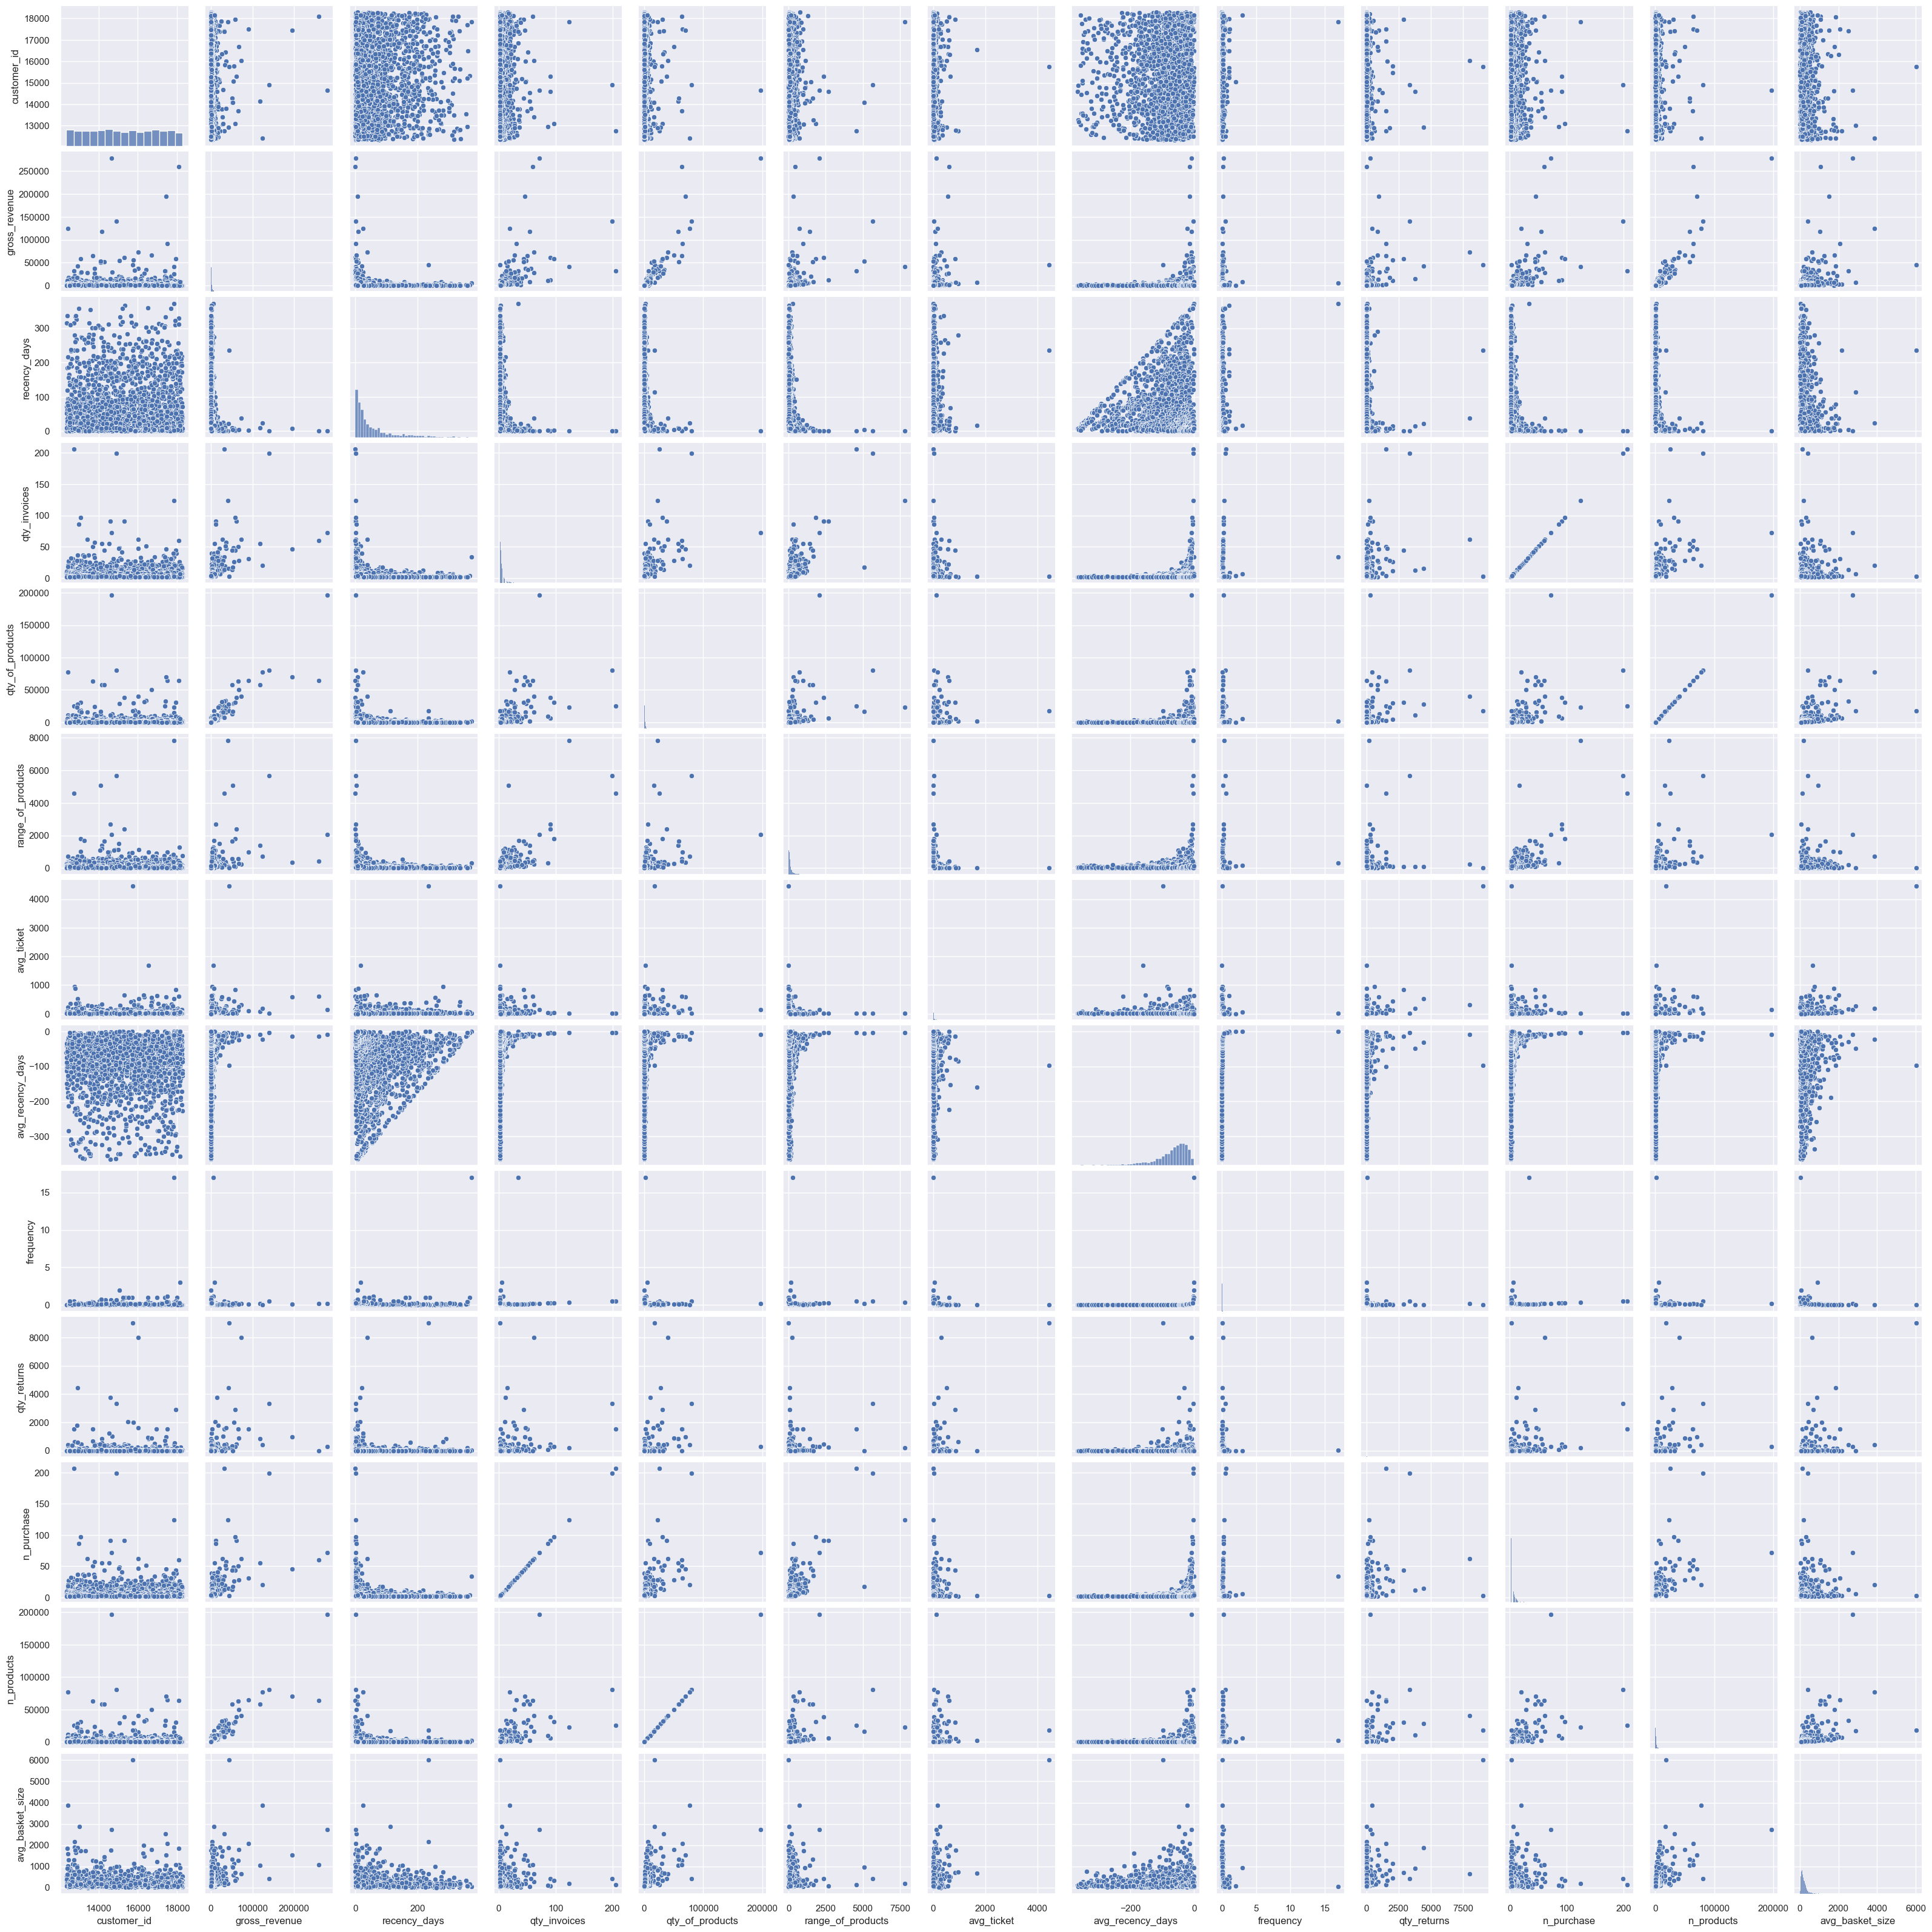

In [42]:
plt.figure( figsize=(12, 15) )
sns.pairplot( df4 )

## 4.3 - Space of Study

In [78]:
# Original Dataset
#df43 = df4.drop( columns=['customer_id'], axis=1 ).copy()

# Selected Dataset
cols_selected = ['customer_id', 'gross_revenue', 'recency_days', 'qty_of_products', 'frequency' , 'qty_returns']
df43 = df4[ cols_selected ]

In [79]:
# Standardization
mms = pp.MinMaxScaler()

# Transformer
df43['gross_revenue']     = mms.fit_transform( df43[['gross_revenue']])
df43['recency_days']      = mms.fit_transform( df43[['recency_days']])
#df43['qty_invoices']      = mms.fit_transform( df43[['qty_invoices']])
df43['qty_of_products']   = mms.fit_transform( df43[['qty_of_products']])
#df43['range_of_products'] = mms.fit_transform( df43[['range_of_products']])
#df43['avg_ticket']        = mms.fit_transform( df43[['avg_ticket']])
#df43['avg_recency_days']  = mms.fit_transform( df43[['avg_recency_days']])
df43['frequency']         = mms.fit_transform( df43[['frequency']])
df43['qty_returns']       = mms.fit_transform( df43[['qty_returns']])
#df43['n_purchase']        = mms.fit_transform( df43[['n_purchase']])
#df43['n_products']        = mms.fit_transform( df43[['n_products']])
#df43['avg_basket_size']   = mms.fit_transform( df43[['avg_basket_size']])

X = df43.copy()

### 4.3.1 - PCA

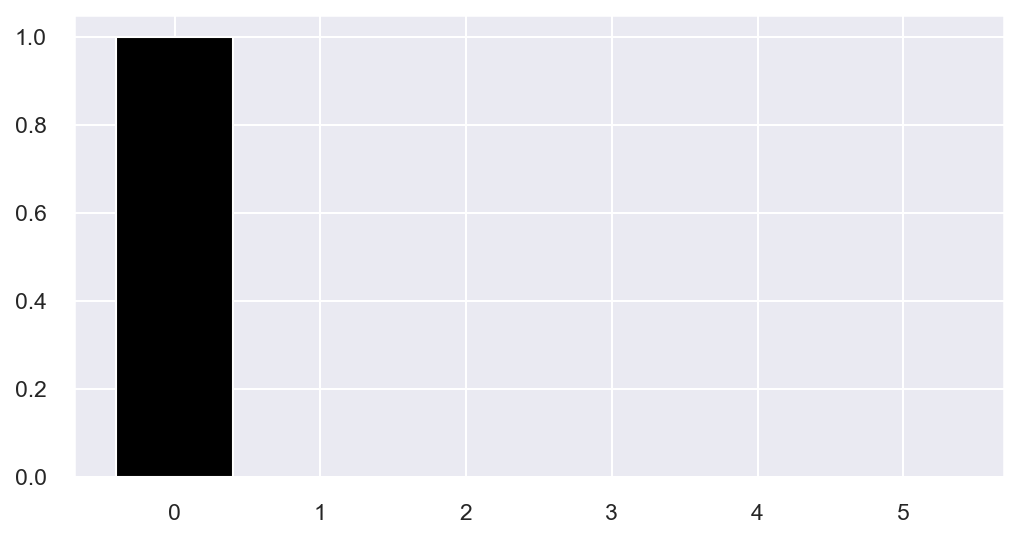

In [80]:
fig, axs = plt.subplots(figsize = (8, 4), dpi=150)
pca = dd.PCA ( n_components = X.shape[1] )

principal_components = pca.fit_transform( X )

# plot explained variables
features = range( pca.n_components_ )

plt.bar( features, pca.explained_variance_ratio_, color='black' )

# pca component

df_pca = pd.DataFrame( principal_components )

<AxesSubplot:xlabel='0', ylabel='1'>

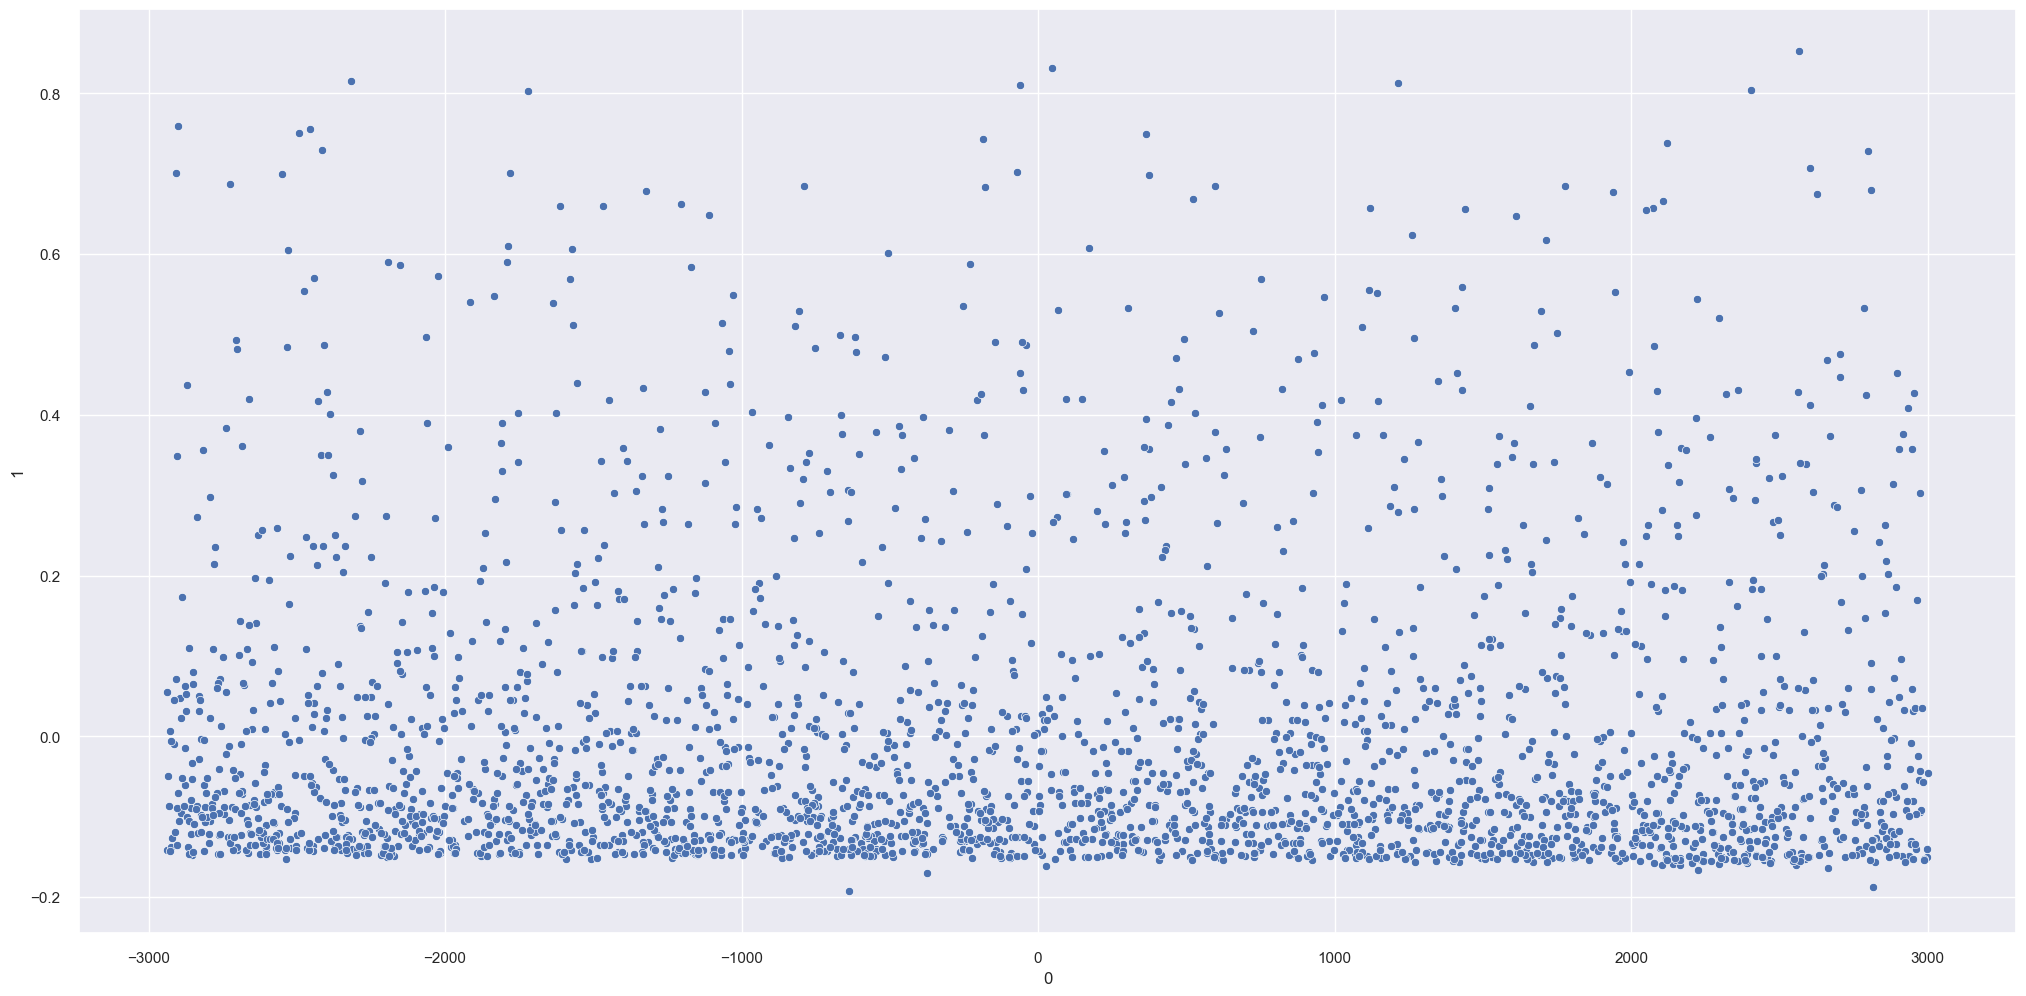

In [81]:
sns.scatterplot( x=0, y=1, data=df_pca)

### 4.3.2 - UMAP

<AxesSubplot:xlabel='embedding_x', ylabel='embedding_y'>

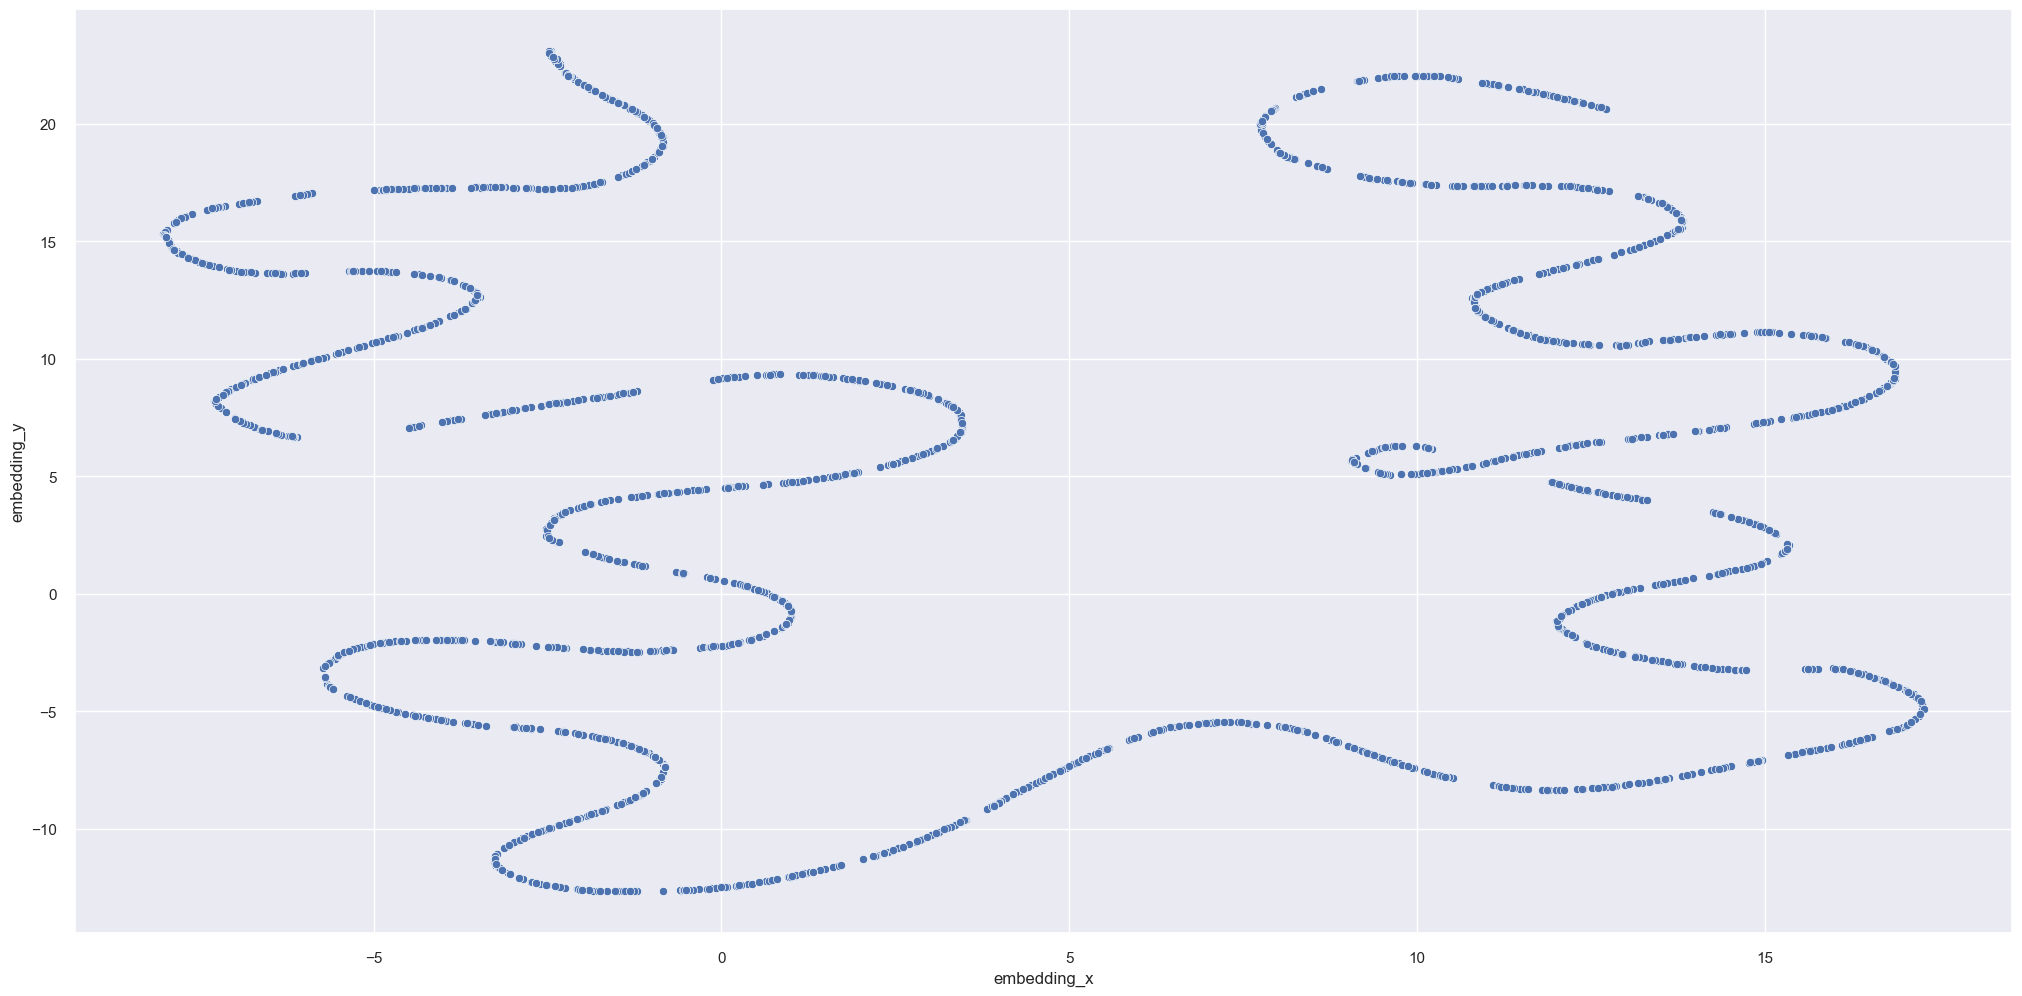

In [82]:
# UMAP 
reducer = umap.UMAP( random_state=42 )
embedding = reducer.fit_transform( X )

# Embedding 
df_pca['embedding_x'] = embedding[:, 0]
df_pca['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y',
                 data=df_pca)
                                

### 4.3.3 - TSNE

<AxesSubplot:xlabel='embedding_x', ylabel='embedding_y'>

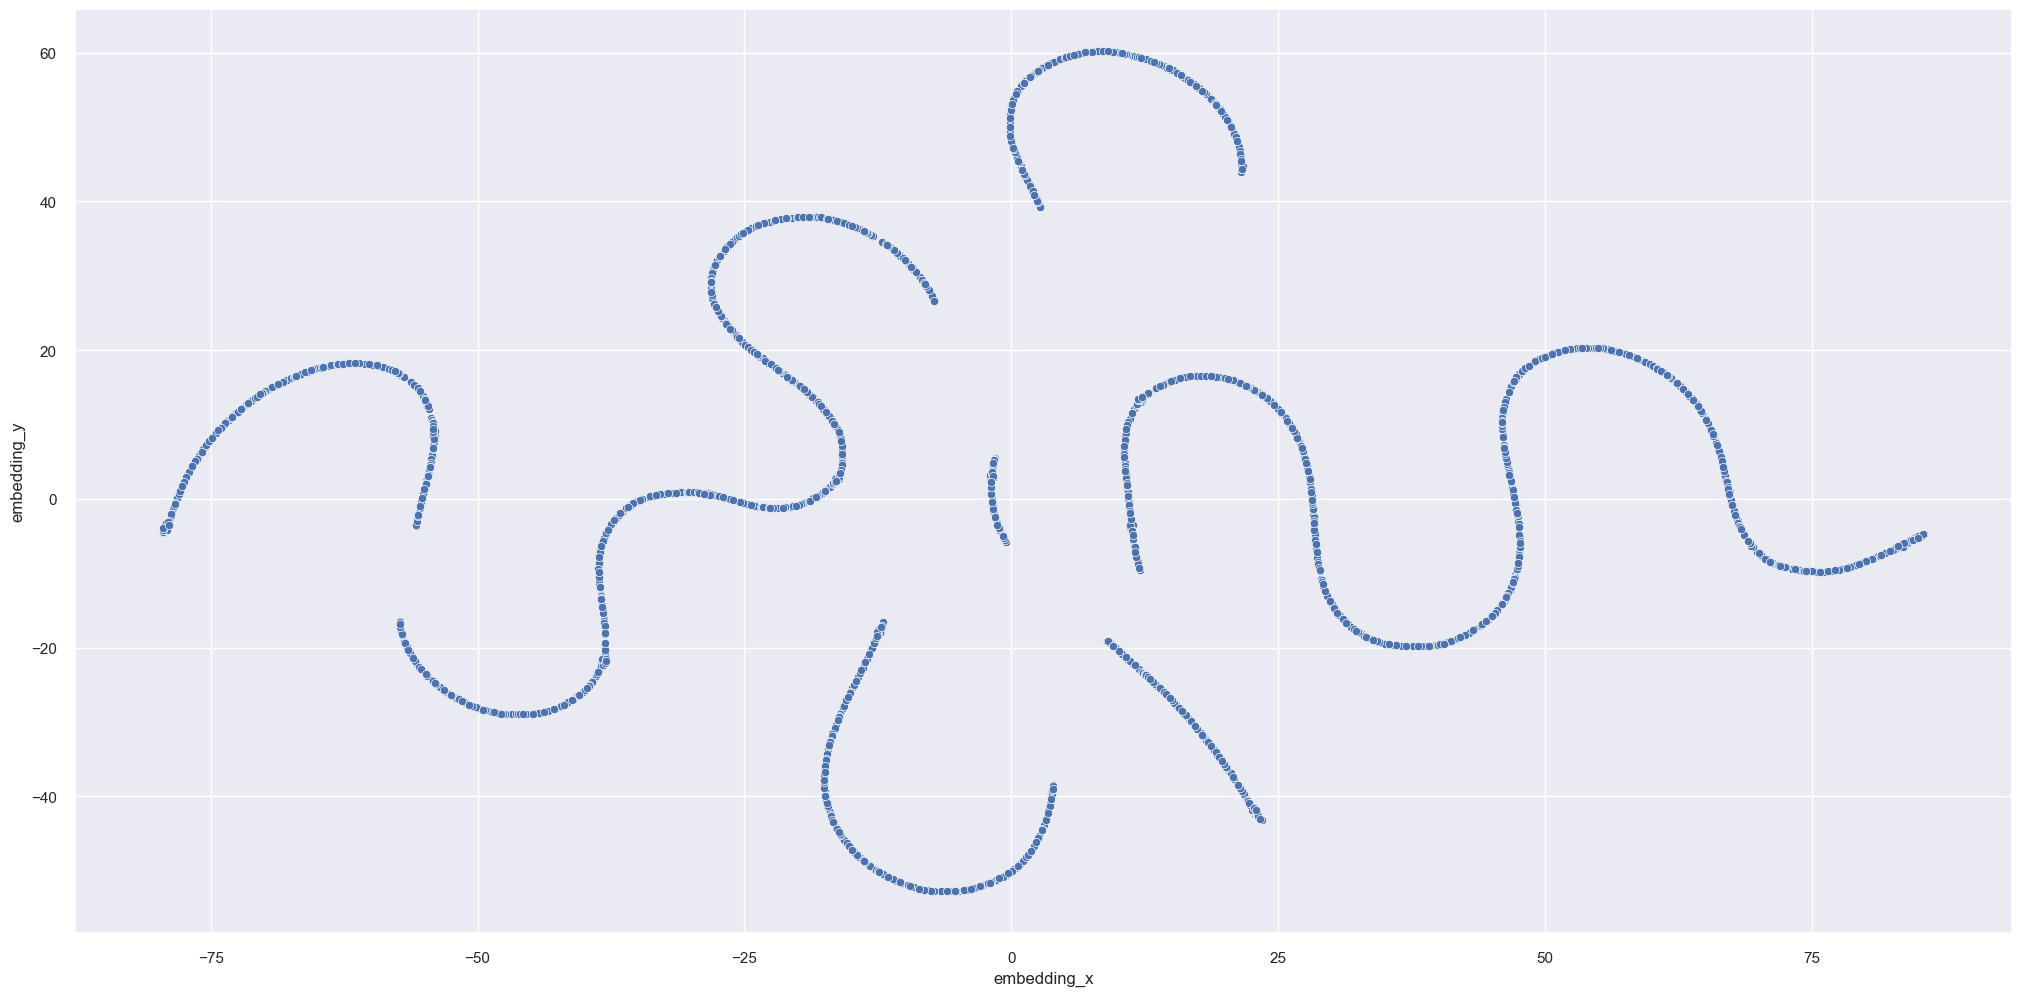

In [83]:
# UMAP 
reducer = TSNE( n_components=2, n_jobs=-1, random_state=42 )
embedding = reducer.fit_transform( X )

# Embedding 
df_pca['embedding_x'] = embedding[:, 0]
df_pca['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y',
                 data=df_pca)
                                

### 4.3.4 - Tree-Based Embedding

In [130]:
# Training dataset
X = df43.drop( columns=['customer_id','gross_revenue'], axis=1 ).copy()
y = df43['gross_revenue']

# model definition
rf_model = en.RandomForestRegressor( n_estimators=100, random_state=42 )

# model trainig
rf_model.fit(X, y)

RandomForestRegressor(random_state=42)

In [131]:
df_leaf = pd.DataFrame( rf_model.apply( X ) ) # here i am selecting the datas from the leaf of tree

<AxesSubplot:xlabel='embedding_x', ylabel='embedding_y'>

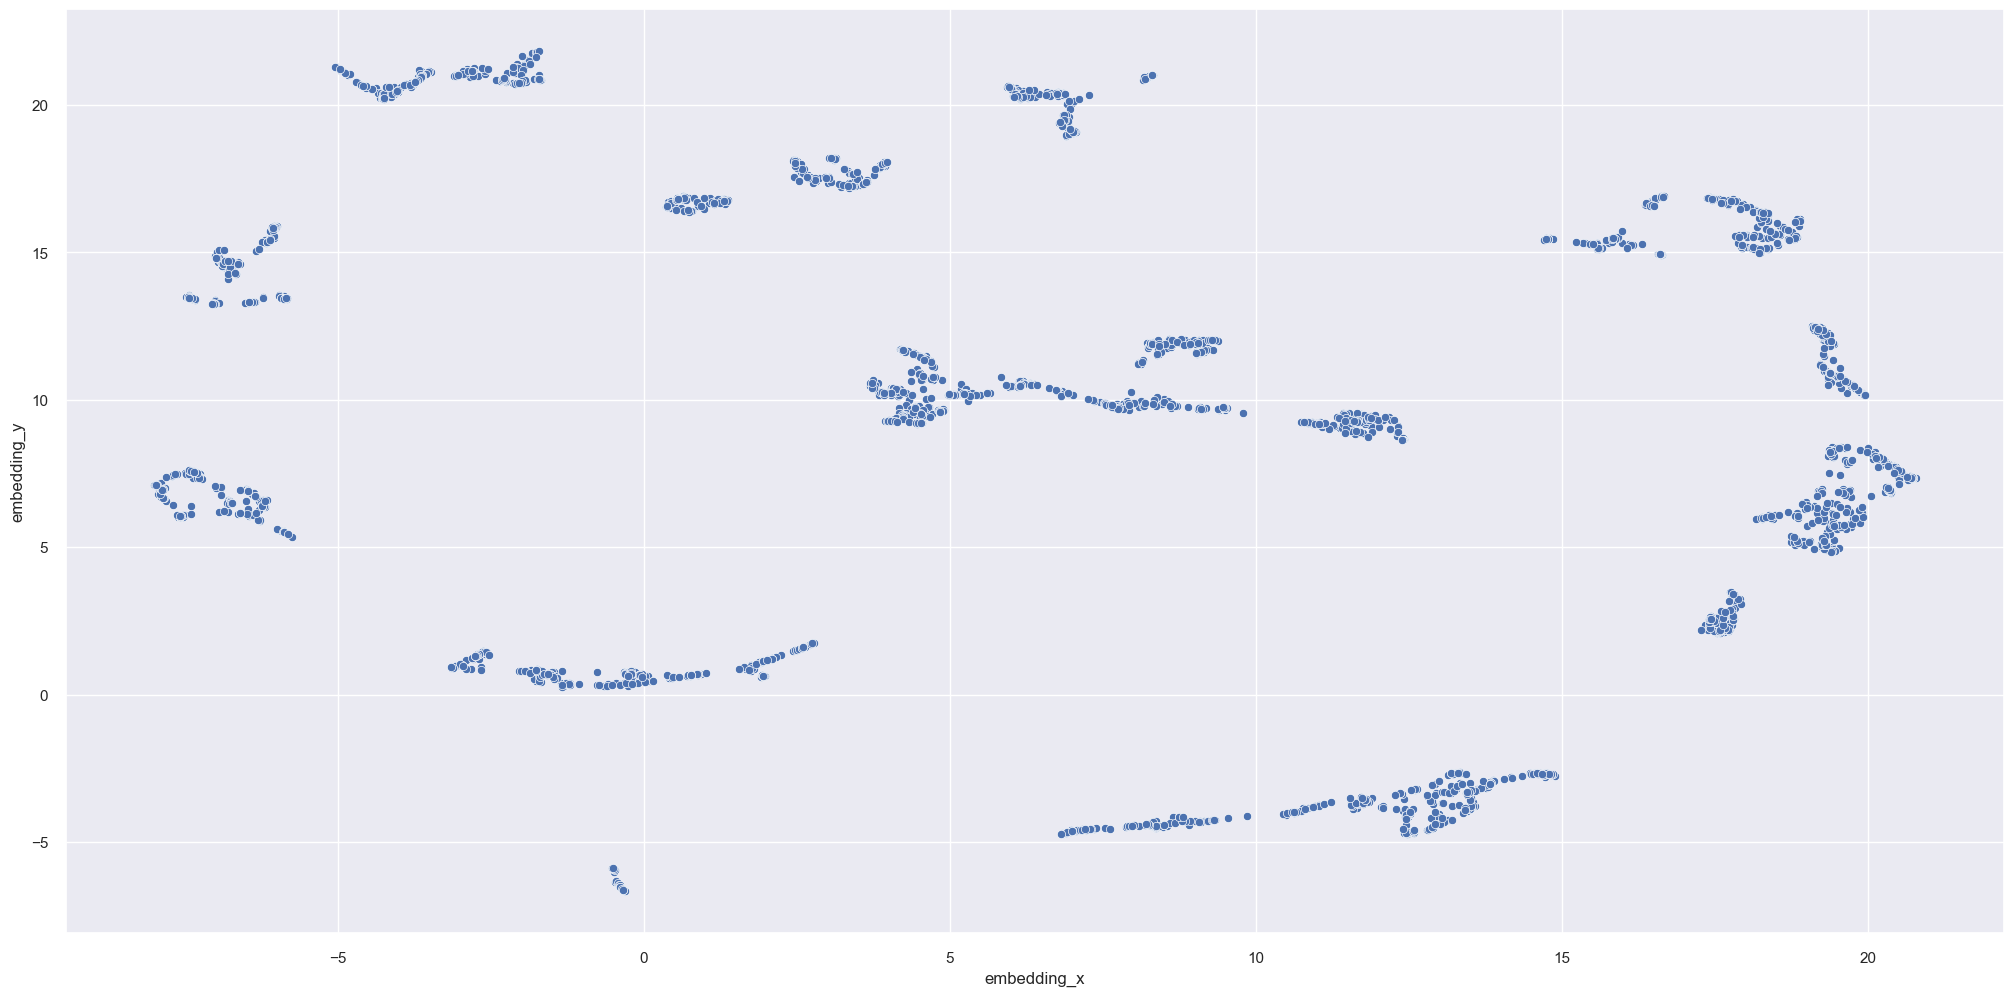

In [132]:
# UMAP 
reducer = umap.UMAP( random_state = 42 )
embedding = reducer.fit_transform( df_leaf )

# Embedding 
df_tree = pd.DataFrame()
df_tree['embedding_x'] = embedding[:, 0]
df_tree['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y',
                 data=df_tree)

# 5 - DATA PREPARATION

Regra

1. Distribuicao Normal e nao possui outliers >>>> Standard Scaler: Media e Desvio Padrao
2. Distribuicao Normal e possui outliers     >>>> Robust Scaler: Quartis
3. Distribuicao Nao Normal                   >>>> Min Max Scaler

Padronizacao -> Premissa de que os dados vieram de uma distribuicao normal
Rescala      -> Premissa de que os dados nao vieram de uma distribuicao normal

4. Metodos para avaliar distribuicao
QQ Plot - Quantile Quantile Plot, se formar reta, distribuicao normal
KS Test - Kolgomorov Smirnoff ( Teste de Hipotese ) Se p-value > 0.5 >>>> Distribuicao Normal, p-value < 0.5 >>>> Distribuicao Nao Normal

5. Deteccao de Outliers
Box Plot  >>>> Pontos sao identificados como outliers
IRQ * 2.5 >>>> Acima deste valor eh outlier
Z-Score > 3  e Z-Score < -3 >>>> Outlier

In [133]:
#df5 = df4.copy()
df5 = df_tree.copy()

#### Standardization

In [53]:
#mm = pp.MinMaxScaler()
#ss = pp.StandardScaler()
#rs = pp.RobustScaler()

#df5['gross_revenue']     = mm.fit_transform( df5[['gross_revenue']])

#df5['recency_days']      = mm.fit_transform( df5[['recency_days']])

#df5['qty_invoices']      = mm.fit_transform( df5[['qty_invoices']])

#df5['qty_of_products']   = mm.fit_transform( df5[['qty_of_products']])

#df5['range_of_products'] = mm.fit_transform( df5[['range_of_products']])

#df5['avg_ticket']        = mm.fit_transform( df5[['avg_ticket']])

#df5['avg_recency_days']  = mm.fit_transform( df5[['avg_recency_days']])

#df5['frequency']         = mm.fit_transform( df5[['frequency']])

#df5['qty_returns']       = mm.fit_transform( df5[['qty_returns']])

#df5['n_purchase']        = mm.fit_transform( df5[['n_purchase']])

#df5['n_products']        = mm.fit_transform( df5[['n_products']])

#df5['avg_basket_size']   = mm.fit_transform( df5[['avg_basket_size']])

#variable = 'qty_of_products'

In [54]:
# Dados AS IS
#print('Min:{} - Max:{}'.format( df5_aux[variable].min(), df5_aux[variable].max() ) )
#sns.displot( df5_aux[variable]);

In [55]:
# Dados Normalizados e Reescalados
#print('Min:{} - Max:{}'.format( df5[variable].min(), df5[variable].max() ) )
#sns.displot( df5[variable]);

In [56]:
# BoxPlot
#sns.boxplot(df5_aux[variable]);

# 6 - FEATURE SELECTION

In [134]:
cols_selected = ['customer_id', 'gross_revenue', 'recency_days', 'qty_of_products', 'frequency' , 'qty_returns']

In [135]:
#df6 = df5[cols_selected].copy()

In [136]:
df6 = df_tree.copy()

# 7 - FINE TUNING

In [137]:
X = df_tree.copy()

In [138]:
cluster = np.arange(2, 19, 1)

In [139]:
X.head()

,embedding_x,embedding_y
0,-7.334082,13.384526
1,-2.847149,20.945024
2,0.754730,0.642929
3,18.169865,16.377062
4,8.717089,-4.179761


## 7.1 - K-Means

In [140]:
kmeans_list = []
for k in cluster:
    # Model Definition
    kmeans_model = cc.KMeans( n_clusters=k )

    # Model Training
    kmeans_model.fit( X )
    # Model Predict
    labels = kmeans_model.predict( X )

    # Model Performance
    sil = mt.silhouette_score( X, labels, metric='euclidean')
    kmeans_list.append( sil )

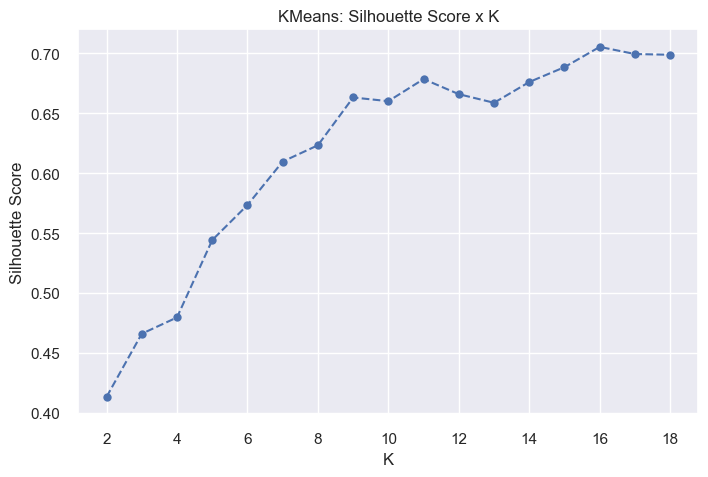

In [141]:
plt.figure( figsize=(8, 5) )
plt.plot( cluster, kmeans_list, linestyle='--', marker='o', color='b')
plt.xlabel( 'K' );
plt.ylabel( 'Silhouette Score');
plt.title('KMeans: Silhouette Score x K');

## 7.2 - Gaussiann Mixture Model

In [142]:
from sklearn import mixture as mx

AIC - Ajuste dos dados
BIC - Ajuste dos parametros

In [143]:
gmm_list = [] 
for k in cluster:
    # Model Definition
    gmm_model = mx.GaussianMixture( n_components=k )
    
    # Model Training
    gmm_model.fit( X )

    # Model Predict
    labels = gmm_model.predict( X )

    # Model Performance
    gmm_sil = mt.silhouette_score( X, labels, metric='euclidean')
    gmm_list.append( gmm_sil )

Text(0.5, 1.0, 'GMM: Silhouette Score x K')

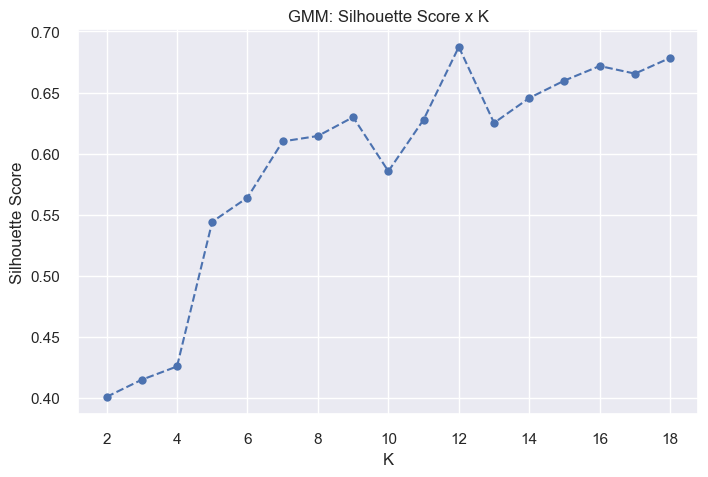

In [144]:
plt.figure( figsize=(8, 5) )
plt.plot( cluster, gmm_list, linestyle='--', marker='o', color='b')
plt.xlabel( 'K' );
plt.ylabel( 'Silhouette Score');
plt.title('GMM: Silhouette Score x K')

## 7.3 - Hierarchical Clustering

In [145]:
from scipy.cluster import hierarchy as hc

In [146]:
# Model Definition and Training
hc_model = hc.linkage( X, 'ward')

[]

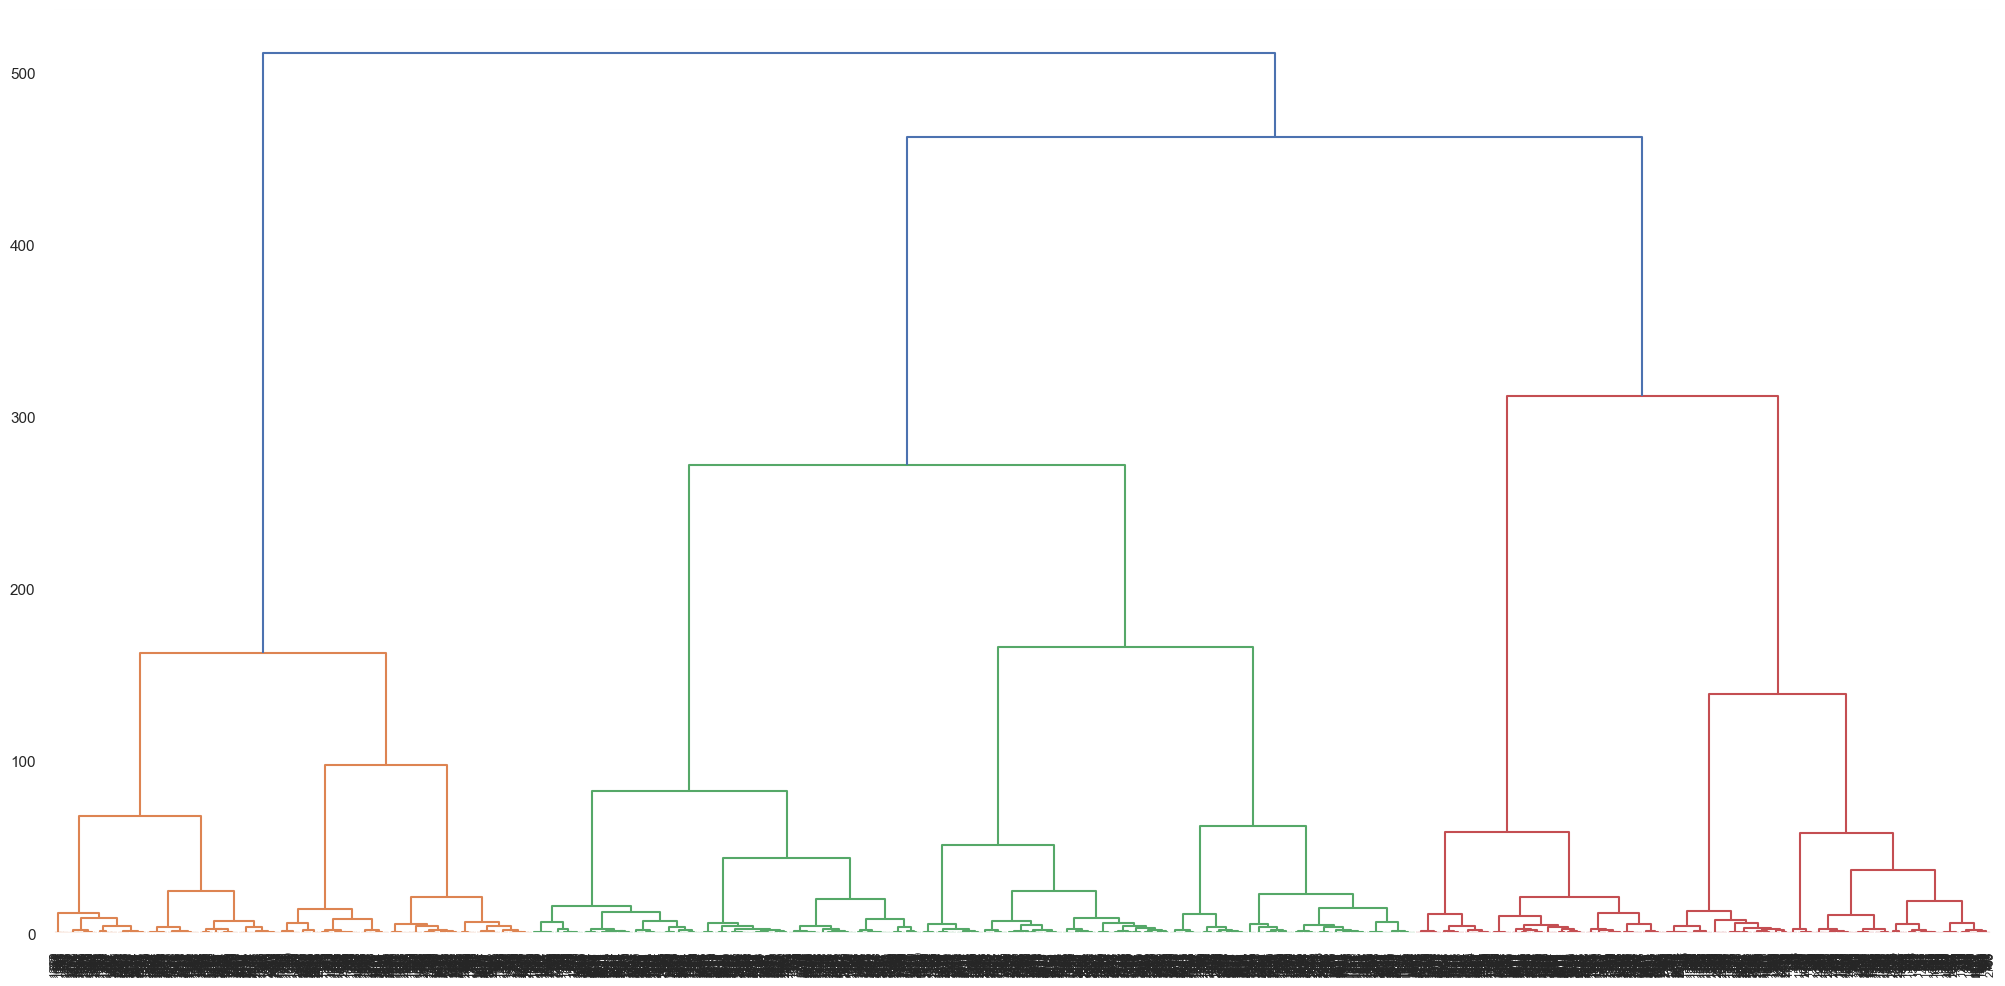

In [147]:
hc.dendrogram(
              hc_model,
              leaf_rotation=90,
              leaf_font_size=8
)

plt.plot()

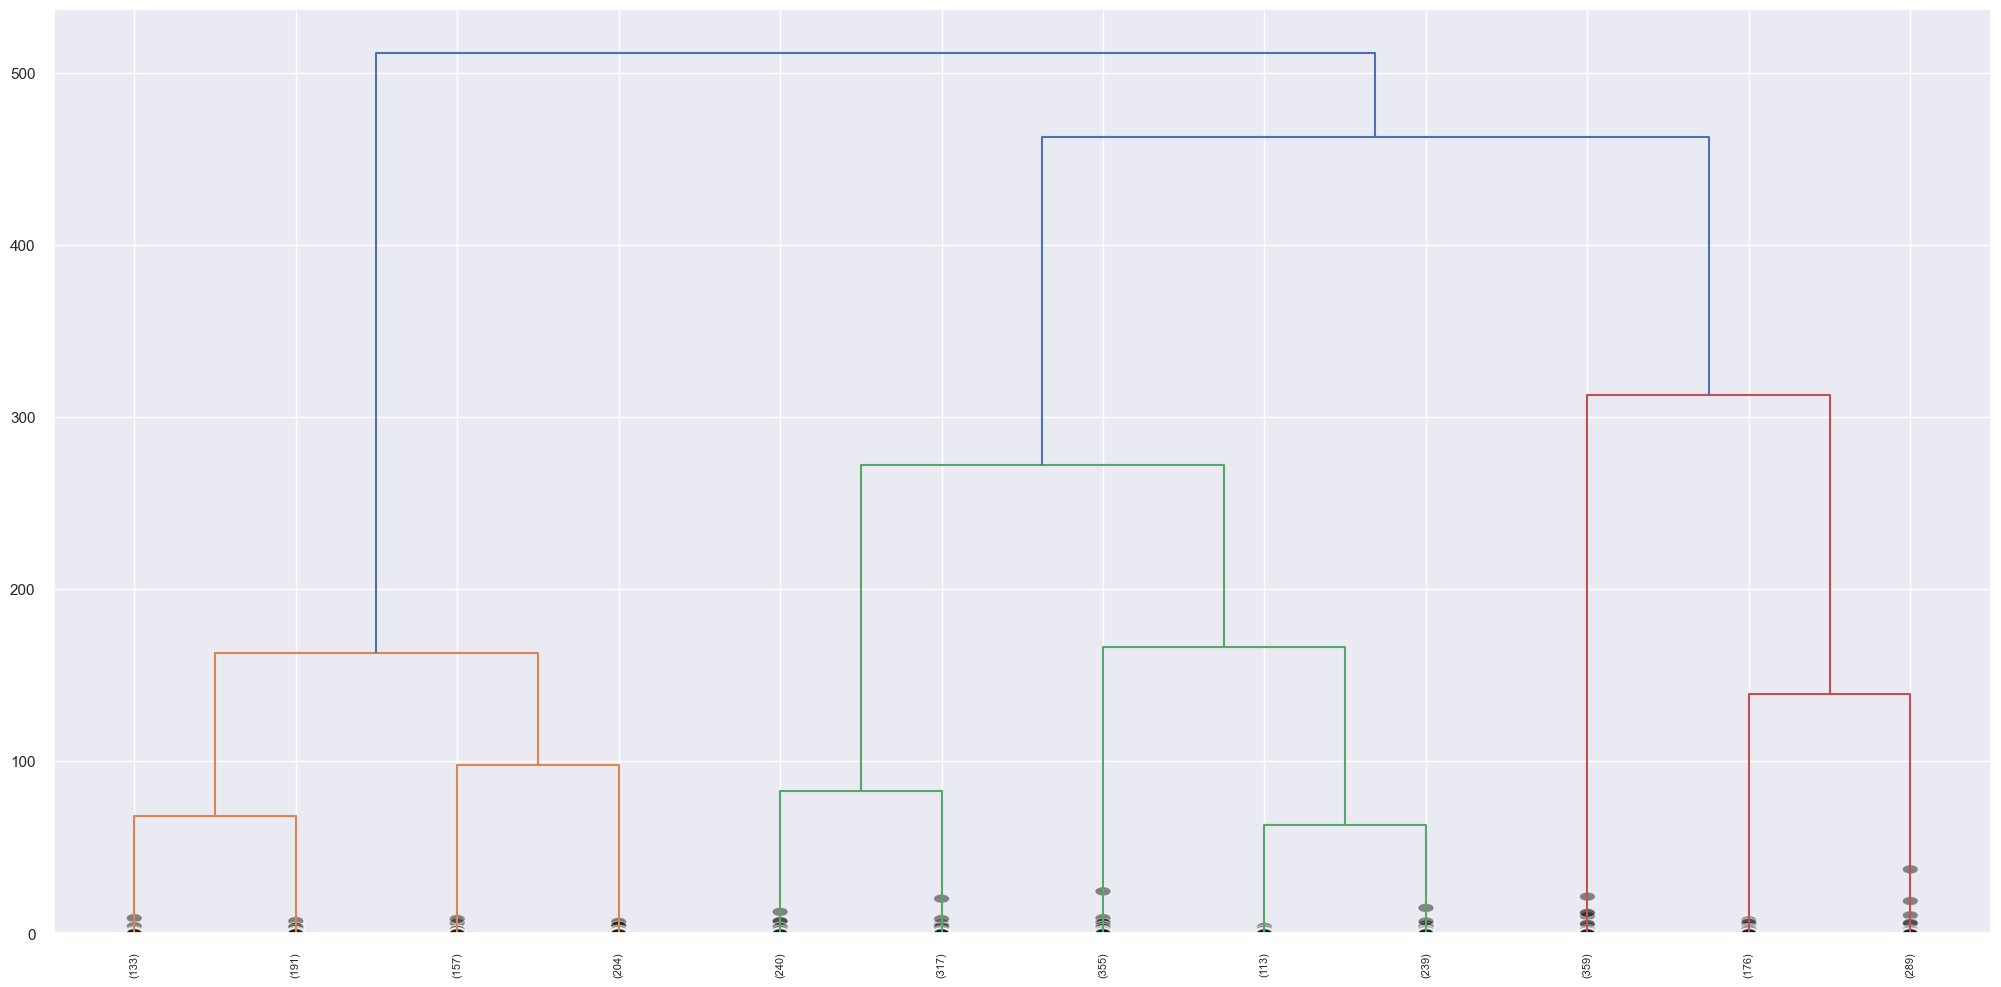

In [148]:
hc.dendrogram(
            hc_model,
            truncate_mode='lastp',
            p=12,
            leaf_rotation=90,
            leaf_font_size=8,
            show_contracted=True
)
plt.show()

### 7.3.1 - Hierarchical Cluster Silhouette

In [149]:
hc_list = []
for k in cluster:
    # Model Definition and Training
    hc_model = hc.linkage( X, 'ward' )

    # Model Predict
    labels = hc.fcluster( hc_model, k, criterion='maxclust' )

    # metrics
    sil = mt.silhouette_score( X, labels, metric='euclidean' )
    hc_list.append( sil )

Text(0.5, 1.0, 'HC: Silhouette Score x K')

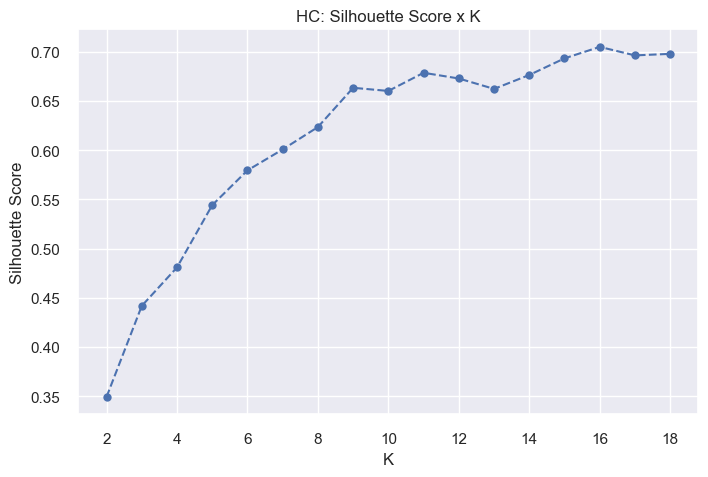

In [150]:
plt.figure( figsize=(8, 5) )
plt.plot( cluster, hc_list, linestyle='--', marker='o', color='b')
plt.xlabel( 'K' );
plt.ylabel( 'Silhouette Score');
plt.title('HC: Silhouette Score x K')

## 7.4 - DBSCAN

In [74]:
eps=0.01
min_samples=20

# Model Definition
dbscan_model = cc.DBSCAN( eps=eps, min_samples=min_samples )

# Model Training and Predict
labels = dbscan_model.fit_predict( X )

db_sil = mt.silhouette_score( X, labels, metric='euclidean' )
print( 'Silhouette Score: {}'.format( sil ) )
print( 'Number of Cluster: {}'.format( len( unique( labels) ) ) )
print( unique( labels ))

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [ ]:
from sklearn.neighbors import NearestNeighbors

In [ ]:
neighbors = NearestNeighbors( n_neighbors = min_samples).fit( X )
distances, indexes = neighbors.kneighbors( X )

In [ ]:
distances = np.sort( distances, axis=0 )
distances = distances[:, 1]

In [ ]:
plt.figure( figsize=(8, 5) )
plt.plot( distances )

## 7.5 - Silhouette Analysis

In [ ]:
fig, ax = plt.subplots( 3, 2 )
fig.set_size_inches( 25, 20 )

for k in cluster:
    q, mod = divmod( k, 2 )
    
    ax[q-1, mod].set_xlim( [-0.1, 1] )
    ax[q-1, mod].set_ylim( [0, len( X ) + ( k+1 )*10] )
    
    # Model Definition and Training
    hc_model = hc.linkage( X, 'ward')

    # Model Predict
    labels = hc.fcluster( hc_model, k, criterion='maxclust')
    
    # Performance
    ss = mt.silhouette_score( X, labels, metric='euclidean')
    print( ' For K = {}. Silhouette Score: {}'.format( k, ss ) )

    
    samples_silhouette_values = mt.silhouette_samples( X, labels )

    y_lower = 10
    for i in range( k ):
        # Select Clusters
        ith_samples = samples_silhouette_values[ labels == i ]

        # Size Clusters
        size_cluster_i = ith_samples.shape[0]
        
        # Sort values
        ith_samples.sort()    

        # Limits
        y_upper = y_lower + size_cluster_i

        ax[q-1, mod].fill_betweenx( np.arange( y_lower, y_upper ), 0, ith_samples )
        
        y_lower = y_upper + 10 
     
        cmap = cm.get_cmap( 'Spectral')
        color = cmap( i/k )
    
    
    
    
ax[q-1, mod].set_yticks([])
ax[q-1, mod].set_xticks([-0.1, 0.2, 0.4, 0.6, 0.8, 1])

## 7.6 - Results

In [ ]:
# Model Name / K=2 / K=3 / K=4 / K=5 / ...
# KMeans       SS    SS    SS    SS
# GMM          SS    SS    SS    SS
# HC           SS    SS    SS    SS
# DBSCAN       SS    SS    SS    SS

In [151]:
df_results = pd.DataFrame(
                          {'KMeans': kmeans_list,
                           'GMM': gmm_list,
                           'HC':hc_list}
).T

df_results.columns = cluster

In [152]:
df_results.style.highlight_max( color='lightgreen', axis=1 ) #identifying the highest value for each ml model

,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
KMeans,0.413275,0.465975,0.479588,0.544147,0.573374,0.609688,0.623276,0.663153,0.660082,0.678528,0.665926,0.658731,0.676072,0.688475,0.705385,0.699426,0.698816
GMM,0.400759,0.414811,0.425675,0.544147,0.563947,0.609958,0.614400,0.629822,0.585544,0.627751,0.687354,0.625095,0.645498,0.659806,0.671696,0.665453,0.678380
HC,0.349325,0.441765,0.480859,0.544147,0.579448,0.600719,0.623460,0.663336,0.660131,0.678587,0.672789,0.662226,0.676351,0.693229,0.704899,0.696254,0.697816


# 8 - MACHINE LEARNING TRAINING

## 8.1 - K-Means

In [153]:
# Model Definition
k = 10
kmeans = cc.KMeans( init='random', n_clusters=k, n_init=10, max_iter=300, random_state=42 )

# Model Trainin
kmeans.fit( X )

# Model Prediction
labels = kmeans.labels_

## 8.2 - GMM

In [112]:
k = 12
# Model Definition
gmm_model = mx.GaussianMixture( n_components=k )
    
# Model Training
gmm_model.fit( X )

# Model Predict
labels = gmm_model.predict( X )

## 8.3 - HC

In [157]:
k=9
# Model Definition and Training
hc_model = hc.linkage( X, 'ward' )

# Model Predict
labels = hc.fcluster( hc_model, k, criterion='maxclust' )

## 8.2 - Cluster Validation

In [154]:
# WSS
print('WSS value: {}'. format( kmeans.inertia_) )

# Silhouette Score
print( 'SS Score: {}'.format( mt.silhouette_score( X, labels, metric='euclidean' ) ) )

WSS value: 15163.408203125
SS Score: 0.6754329204559326


# 9 - CLUSTER ANALYSIS

In [158]:
df9 = X.copy()
df9['cluster'] = labels
df9.head()

,embedding_x,embedding_y,cluster
0,-7.334082,13.384526,2
1,-2.847149,20.945024,3
2,0.754730,0.642929,9
3,18.169865,16.377062,6
4,8.717089,-4.179761,7


## 9.1 - Vizualization Inspection


<AxesSubplot:xlabel='embedding_x', ylabel='embedding_y'>

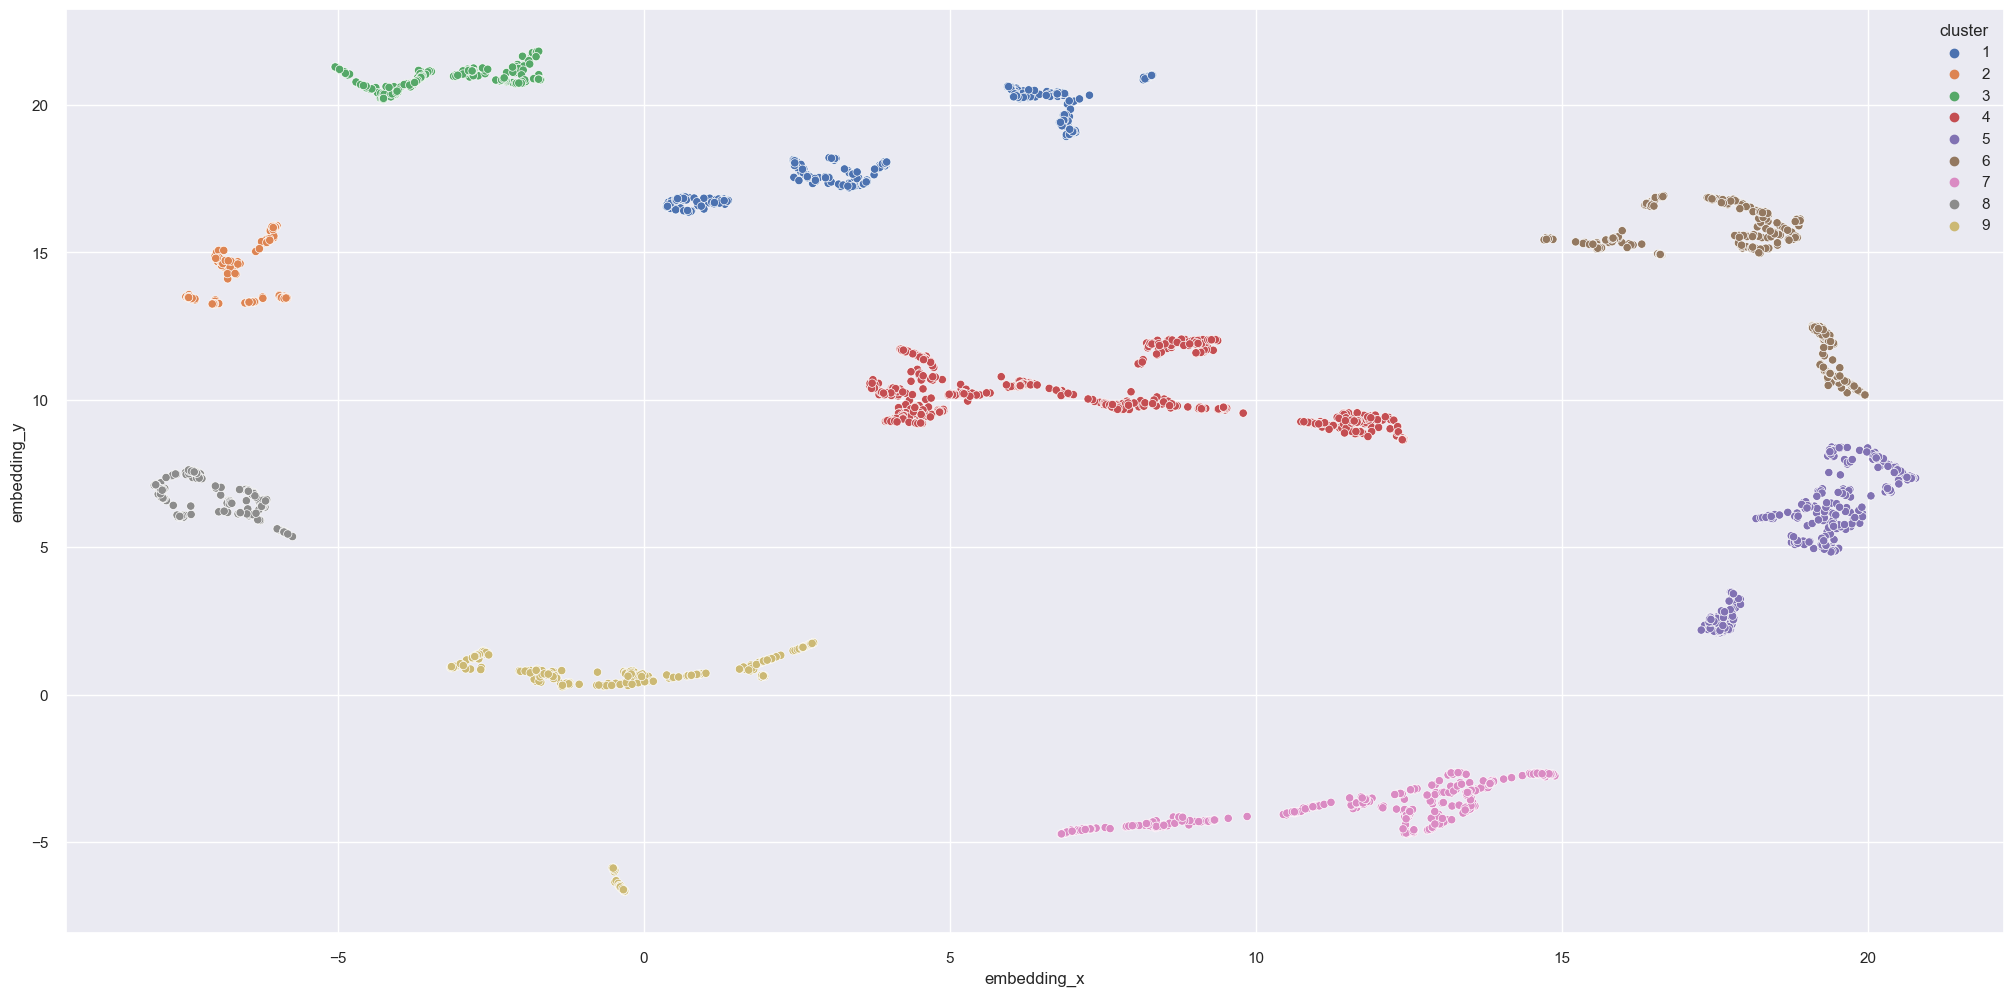

In [159]:
sns.scatterplot( x='embedding_x', y='embedding_y', hue='cluster', data=df9, palette='deep')

In [160]:
# Silhouette 4 clusters
# visualizer = SilhouetteVisualizer( kmeans, colors='yellowbrick' )
# visualizer.fit( X )
# visualizer.finalize()

## 9.2 - 2D Plot

In [ ]:
# df_viz = df9.drop( columns='customer_id', axis=1)
# sns.pairplot( df_viz, hue='cluster')

## 9.3 - UMAP

Machine Learning - Manifold

Aprendizado por topologia: PCA - Metodo baseado em matriz ou espaco entre distancias. Temos 9 condicoes, cumprir 9 colorarios para ter uma garantia de espaco. Espaco de Hilbert, etc.AffinityPropagation

UMAP, T-SNE ( 2009 )- Abordagem por topologia ( Manifold ). Topologia sao grafos em alta dimensionalidade

In [ ]:
# UMAP 
reducer = umap.UMAP(n_neighbors=90, random_state=42)
embedding = reducer.fit_transform( X )

# Embedding 
df_viz['embedding_x'] = embedding[:, 0]
df_viz['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y', 
                 hue='cluster',
                 palette=sns.color_palette('hls',
                                           n_colors=len(df_viz['cluster'].unique())),
                 data=df_viz)
                                           


In [ ]:
cols_selected

## 9.4 - Cluster Profile

In [161]:
df94 = df4[ cols_selected ].copy()
df94['cluster'] = labels
df94.head()

,customer_id,gross_revenue,recency_days,qty_of_products,frequency,qty_returns,cluster
0,17850,5391.21,372.0,1733.0,17.000000,40.0,2
1,13047,3232.59,56.0,1390.0,0.028302,35.0,3
2,12583,6705.38,2.0,5028.0,0.040323,50.0,9
3,13748,948.25,95.0,439.0,0.017921,0.0,6
4,15100,876.00,333.0,80.0,0.073171,22.0,7


In [162]:
# Number of Customer
df_cluster = df94[['customer_id', 'cluster']].groupby('cluster').count().reset_index()
df_cluster['perc_customer'] = 100*( df_cluster['customer_id'] / df_cluster['customer_id'].sum() )

# Avg Gross Revenue
df_avg_gross_revenue = df94[['gross_revenue', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_gross_revenue, how='inner', on='cluster')

# Avg Recency Days
df_avg_recency_days = df94[['recency_days', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_recency_days, how='inner', on='cluster')

# Avg Qty Products
df_qty_product = df94[['qty_of_products', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_qty_product, how='inner', on='cluster')

# Avg Frequency
df_freq = df94[['frequency', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_freq, how='inner', on='cluster')

# Avg Returns
df_ret = df94[['qty_returns', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_ret, how='inner', on='cluster')
df_cluster

,cluster,customer_id,perc_customer,gross_revenue,recency_days,qty_of_products,frequency,qty_returns
0,1,324,11.684097,1799.019383,43.959877,1059.253086,0.032541,17.521605
1,2,157,5.661738,2902.339045,35.484076,1791.751592,0.139488,28.961783
2,3,204,7.356653,2353.203480,43.073529,1431.808824,0.030882,18.083333
3,4,557,20.086549,1222.125117,54.364452,676.888689,0.038422,12.552962
4,5,355,12.802019,570.193268,77.377465,273.281690,0.041783,3.828169
5,6,352,12.693833,808.390909,72.551136,416.198864,0.043488,5.275568
6,7,359,12.946268,356.973705,96.417827,133.019499,0.054154,2.328691
7,8,176,6.346917,3900.387727,27.022727,2323.420455,0.036884,36.562500
8,9,289,10.421926,15184.731938,20.152249,9142.024221,0.074868,226.955017


# 10 - EXPLORATORY DATA ANALYSIS

## 10.1 - Mind Map of Hypothesis

## 10.2 - Business Hypothesis

## 10.3 - Hypothesis Pryority

## 10.4 - Hypothesis Validation

## 10.5 - Answers

# 11 - DEPLOY